# Lab #1: Absolute and relativity humidity and the saturation water vapor of density air.
### Farhan Ariff bin Halis Azhan
### Collaborators
* Name
* Name

## Goal and Introduction
The goal for this lab is to investigate the relationship between the absolute and relativiy humidity of the surrounding (air/dew point temperature) and the saturation water vapor of density air ($p$ / $p_{sat}$). After that, we will find out the fraction of both days in July and Februrary that was "comfortable" (relative humidity below 70%.)

## Data
There are two datasets, which are CSRB_20040214.csv and CSRB_20040716.csv. The first dataset was taken on a day in February, at CSRB, during Ann Arbor's  winter season, while the second dataset was taken on a day in July, at the same place, during Ann Arbor's summer season. Both files contain information about Surface meteorological data of the CSRB building, specificially, date and time, pressure (hPa), airtemp(degree Celcius), and dptemp (in degree Celcius). There is no quality/pre-processing of datasets before analysis.

----

## Approach and Results
Describe your approach for each question in the lab description and interpretation of the results for that question.
Start with an over-arching paragraph to describe your approach as you see fit.

I will start with a code cell that imports critical packages and the variables that will hold the name for files that needs to be read.


In [2]:
# Import critical libraries:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

# Turn on in-line plotting:
%matplotlib inline

# Some shortcut variables:
winter = './CSRB_20040214.csv'
summer = './CSRB_20040716.csv'

### Question 1
Code up the algorithm for saturation water vapor density as a python function
that takes air temperature as an input in units of ◦C and outputs the saturation water vapor
density in g m−3. 

Test the function and demonstrate that it works by calling it to calculate
the saturation water vapor density for temperatures ranging from -10◦C to +40◦C 

(Hint:
pass a Numpy array created using the (np.arange) function). 

Create a plot of temperature
vs. saturation water vapor density over this temperature range.


In [3]:
def water_vapor_density(temp):
    '''
    This function will receive temperature as a parameter, then will in turn return
    water vapor density of that temperature.
    
    Example usage:
    Give the function temp as a variable, then see the value of the returned wated_density
    >>> water_density = water_vapor_density(temp)
    >>> print(water_density)
    '''
    # E/e (not that weird "e") is scientific notation for "10 to the power of ..."
    # These value was obtained from (3) from Lab01.pdf
    c0 = -2.915127
    c2 = 1.124901e-3
    c4 = -1.58311e-7
    c6 = 1.23218e-11
    # This is formula 2 from pdf using the aforementioned value from (3)
    water_density = c0 + c2 * ((temp + 100) ** 2) + c4 * ((temp + 100) ** 4) + c6 * ((temp + 100) ** 6)
    
    # return saturation water vapor density from said temp
    return water_density

In [4]:
# Test function, calculate water_vapor_density for temperatures ranging from -10 to 40
temp = np.arange(-10.0, 40.0, 1)
water_density = water_vapor_density(temp)

Text(0, 0.5, '$P_{saturation}$(g/$m^{-3}$)')

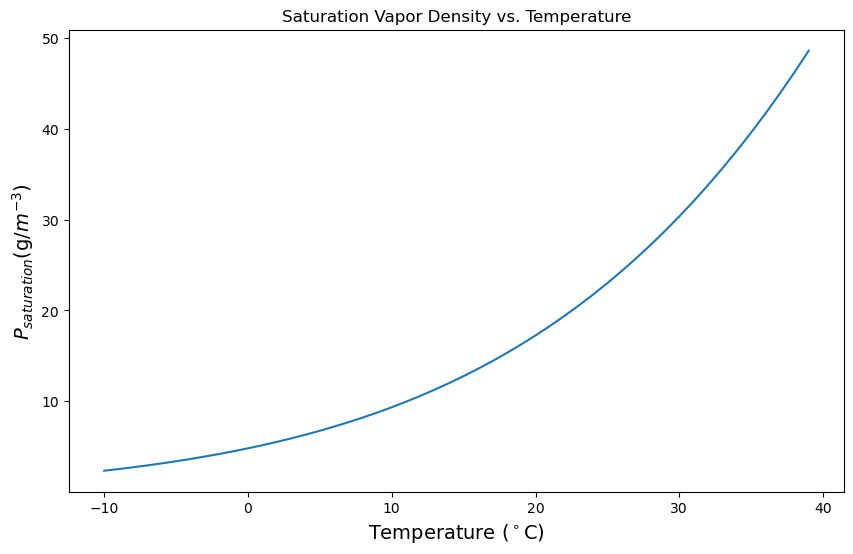

In [5]:
# Create a plot of temperature vs saturation water vapor density 
# over the range of -10 to 40 degree celcius
fig = plt.figure(figsize=(10,6))
ax1 = fig.subplots(1,1)
# Plotting temp as x axis and water_density as y axis
ax1.plot(temp, water_density)
# setting the title, x label and y label
ax1.set_title('Saturation Vapor Density vs. Temperature')
ax1.set_xlabel('Temperature ($^\circ$C)', size = 14)
ax1.set_ylabel('$P_{saturation}$(g/$m^{-3}$)', size = 14)

### Question 2
Write a function that reads the two data files, CSRB 20040716.csv and CSRB 20040214.csv.


Use Numpy’s genfromtxt function to do this following a similar procedure as Lab00. 

Note that there are more header lines, so you may need to employ the skip head= keyword
argument. 

Further, the variable names given in the file may be unwieldy. Consider using the names= keyword argument to explicity set variable names. 

Confirm that your function works for each file.


In [6]:
# Write a function that reads the two data files, CSRB 20040716.csv and CSRB 20040214.csv.
# Use Numpy’s genfromtxt function to do this following a similar procedure as Lab00. 
# Note that there are more header lines, so you may need to employ the skip head= keyword argument. 
# Further, the variable names given in the file may be unwieldy. Consider using the names= keyword argument to explicity set variable names. 

def read_csv(filename):
    '''
    This function will read csv file and will then return a dictionary datatype.
    
    Example usage:
    give filename as parameter, then see the first or last line of the returned data
    >>> data = read_cvs(filename)
    >>> print(f"The first line of data is {data[0]}")
    >>> print(f"The last line of data is {data[-1]}")
    '''    
    # create a function to convert a time entry
    tconvert = lambda x: dt.datetime.strptime(str(x), '%Y-%m-%dT%H:%M:%S')
    # using genfromtxt function to extract data from csv file into data variable
    data = np.genfromtxt(filename, names=True, delimiter=',', encoding='utf-8',
                         converters={0:tconvert}, dtype=None, skip_header = 3)
    
    # return data
    return data

In [7]:
# read CSRB_20010716.csv, so it is taken during one summer day
summer_data = read_csv(summer)
# read CSRB_20010214.csv, so it is taken during one winter day
winter_data = read_csv(winter)

In [8]:
# Confirm that function works for each file.
print("The last line of summer July file is : 2004-07-16T23:59:37,1015.7,19.4,17.2")
print("The last line from summer data is : ", summer_data[-1])
print("The last line of winter February file is : 2004-02-14T23:59:50,1018.2,1.8,-5.3")
print("The last line from winter data is : ", winter_data[-1])

The last line of summer July file is : 2004-07-16T23:59:37,1015.7,19.4,17.2
The last line from summer data is :  (datetime.datetime(2004, 7, 16, 23, 59, 37), 1015.7, 19.4, 17.2)
The last line of winter February file is : 2004-02-14T23:59:50,1018.2,1.8,-5.3
The last line from winter data is :  (datetime.datetime(2004, 2, 14, 23, 59, 50), 1018.2, 1.8, -5.3)


In [9]:
# print out the names of the data's variable names
print(summer_data.dtype.names)

('date_and_time', 'pressure_hPa', 'airtemp_deg_C', 'dptemp_deg_C')


### Question 3
The above files do not have explicit information about the absolute humidity (ρ), but does have the dew point temperature (TDP ). 

Use TDP with your saturation vapor density function from Part 1 to calculate ρ for each day. 

Then, calculate the saturation vapor density (ρsat) using the temperature data for each day. 

Finally, calculate the relative humidity (RH) using the formula in Equation 1. Explain why we can use TDP to get ρ.

In [10]:
# 1. Use TDP with your saturation vapor density function from Part 1 to calculate ρ for each day.
summer_data_TDP = summer_data['dptemp_deg_C']
winter_data_TDP = winter_data['dptemp_deg_C']

# calculate rho (p) of both data using the formula 2 from pdf using TDP
summer_actual_density = water_vapor_density(summer_data_TDP)
winter_actual_density = water_vapor_density(winter_data_TDP)
# now we have p

# 2. Then, calculate the saturation vapor density (ρsat) using the temperature data for each day. 
# find which index has the airtemp
# OR instead of index number, we use the title/varname of what we want
summer_data_airtemp = summer_data['airtemp_deg_C']
winter_data_airtemp = winter_data['airtemp_deg_C']

# calculate (psat) of both data using the formula 2 from pdf using airtemp 
summer_saturated_density = water_vapor_density(summer_data_airtemp)
winter_saturated_density = water_vapor_density(winter_data_airtemp)
# now we have psat

# 3. Finally, calculate the relative humidity (RH) using the formula 1 from pdf 
# using the obtained p and psat. 
summer_RH = summer_actual_density/summer_saturated_density
winter_RH = winter_actual_density/winter_saturated_density

#### Explain why we can use $T_{DP}$ to get ρ.  
Dew point temperature ($T_{DP}$) is the air temperature in which water vapor density p would be saturated. By applying the function from question 1, we can get p by using Dew Point Temperature as the input.


### Question 4
Compute the minimum, maximum, mean and median values of air temperatures,
absolute humidity, and relative humidity for each day. 

Present your results in a table in your lab report (look up Markdown syntax for creating tables in Jupyter). 

Include descriptive names for the rows and columns in the table and make sure to include units for all variables.


How do the two days compare to each other?

In [11]:
# 1. Compute the minimum, maximum, mean and median values of air temperatures, 
# absolute humidity, and relative humidity for each day.

# Data for summer day
summer_airtemp = [np.min(summer_data_airtemp) , np.max(summer_data_airtemp),
                  np.mean(summer_data_airtemp), np.median(summer_data_airtemp)]
summer_absolute_humidity = [np.min(summer_actual_density) , np. max(summer_actual_density), 
                            np.mean(summer_actual_density), np.median(summer_actual_density)]
summer_relative_humidity = [np.min(summer_RH) , np. max(summer_RH), 
                            np.mean(summer_RH), np.median(summer_RH)]
# Data for winter day
winter_airtemp = [np.min(winter_data_airtemp) , np. max(winter_data_airtemp), 
                  np.mean(winter_data_airtemp), np.median(winter_data_airtemp)]
winter_absolute_humidity = [np.min(winter_actual_density) , np. max(winter_actual_density), 
                            np.mean(winter_actual_density), np.median(winter_actual_density)]
winter_relative_humidity = [np.min(winter_RH) , np. max(winter_RH), 
                            np.mean(winter_RH), np.median(winter_RH)]

# print Summer data
print(summer_airtemp)
print(summer_absolute_humidity)
print(summer_relative_humidity)

# print winter data
print(winter_airtemp)
print(winter_absolute_humidity)
print(winter_relative_humidity)

[15.1, 23.8, 18.247222222222224, 17.2]
[12.852542689624393, 15.318376290395118, 14.094882258811877, 14.081044097351892]
[0.6658475497714481, 1.0, 0.9130254568505523, 0.9644085787770861]
[-4.6, 5.1, -0.07906249999999994, 1.3]
[2.560127306277171, 3.4002298885281252, 2.9504871286767087, 2.986850817862676]
[0.4417830476094997, 0.7822461227688882, 0.6240702777514296, 0.6316785319557102]


2. Present your results in a table in your lab report (look up Markdown syntax for creating tables in Jupyter).
3. Include descriptive names for the rows and columns in the table and make sure to include units for all variables

|July|airtemp ($\circ$C) | absolute_humidity (g $m^{-3}$)| relativity_humidity (%)|
|:----:|:-----------------------:|:-------------------------:|:----------------------:|
|min|15.1|12.85|0.67|
|max|23.8|15.32|1.0|
|mean|18.25|14.10|0.91|
|median|17.2|14.10|0.96|

|February|airtemp ($\circ$ C) | absolute_humidity (g $m^{-3}$)| relativity_humidity (%)|
|:----:|:-----------------------:|:-------------------------:|:----------------------:|
|min|-4.6|2.56|0.44|
|max|5.1|3.40|0.78|
|mean|-0.08|2.95|0.62|
|median|1.3|2.99|0.63|

#### How do the two days compare to each other?

July has bigger minimum air temperature compared to February's minimum air temperature. This in turn, lead to July having bigger minimum absolute humidity and relative humidity compared to February's minimum absolute humidity and  relative humidity.
In closer inspection, almost every entry in July is bigger than February's respective entry. Thus we can conclude that July overall can hold bigger water vapor density than February.

### Question 5
Generate two plots (one for each day) to display your results. 

Each plot should be composed of two subplots. The upper subplot should show both the air and dew point
temperatures versus time. 

The lower subplot should show the relative humidity versus time. 

Make sure to use different line styles for the two temperatures and annotate the plot using python legends. 

What information did you gain from these plots beyond what you learned from the table?

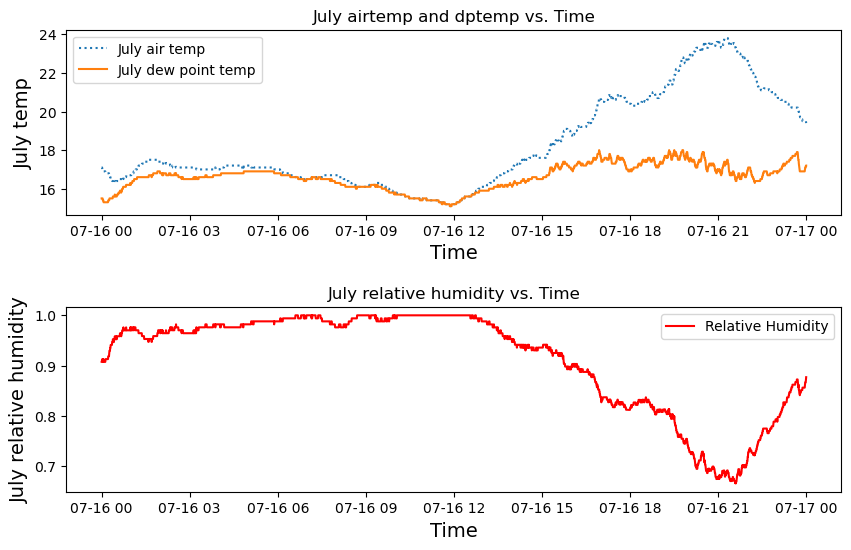

In [12]:
# FOR July
# 1. Generate two plots (one for each day) to display your results. 
fig5summer = plt.figure(figsize=(10,6))
# ax51summer for upperplote, ax52summer for lowersubplot
ax51summer, ax52summer = fig5summer.subplots(2,1)
# 2. Each plot should be composed of two subplots. 
# The upper subplot should show both the air and dew point temperatures versus time. 
ax51summer.plot(summer_data['date_and_time'], summer_data_airtemp, 
                label="July air temp", ls='dotted')
ax51summer.plot(summer_data['date_and_time'], summer_data_TDP,
               label="July dew point temp", ls = 'solid')
ax51summer.set_title('July airtemp and dptemp vs. Time')
ax51summer.set_xlabel('Time', size = 14)
ax51summer.set_ylabel('July temp', size = 14)
# 3. The lower subplot should show the relative humidity versus time. 
ax52summer.plot(summer_data['date_and_time'], summer_RH,
               label = 'Relative Humidity', color='red')
ax52summer.set_title('July relative humidity vs. Time')
ax52summer.set_xlabel('Time', size = 14)
ax52summer.set_ylabel('July relative humidity', size = 14)
# 4. Make sure to use different line styles for the two temperatures 
# and annotate the plot using python legends.
ax51summer.legend()
ax52summer.legend()
# Put space between subplots
plt.subplots_adjust(hspace = 0.5)

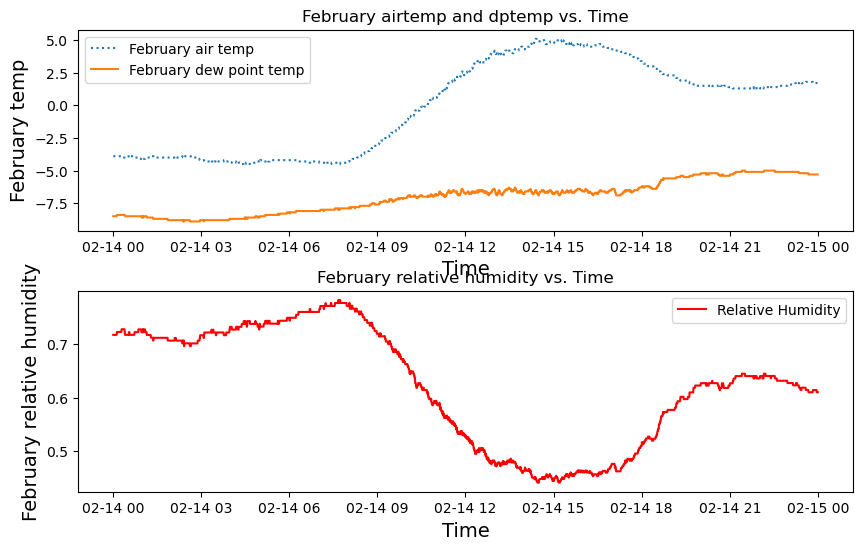

In [16]:
# FOR February
# 1. Generate two plots (one for each day) to display your results. 
fig5winter = plt.figure(figsize=(10,6))
# ax51winter for upperplote, and ax52winter for lowersubplot
ax51winter, ax52winter = fig5winter.subplots(2,1)
# 2. Each plot should be composed of two subplots. The upper subplot should show both the air and dew point
# temperatures versus time. 
ax51winter.plot(winter_data['date_and_time'], winter_data_airtemp, 
                label="February air temp", ls='dotted')
ax51winter.plot(winter_data['date_and_time'], winter_data_TDP, 
                label="February dew point temp", ls='solid')
ax51winter.set_title('February airtemp and dptemp vs. Time')
ax51winter.set_xlabel('Time', size = 14)
ax51winter.set_ylabel('February temp', size = 14)
# 3. The lower subplot should show the relative humidity versus time. 
ax52winter.plot(winter_data['date_and_time'], winter_RH,
               label="Relative Humidity", color='red')
ax52winter.set_title('February relative humidity vs. Time')
ax52winter.set_xlabel('Time', size = 14)
ax52winter.set_ylabel('February relative humidity', size = 14)
# 4. Make sure to use different line styles for the two temperatures and 
# annotate the plot using python legends.
ax51winter.legend()
ax52winter.legend()
# Put space between subplots
plt.subplots_adjust(hspace = 0.3)

#### 5. What information did you gain from these plots beyond what you learned from the table?

February's relative humidity was below 0.7 longer than when it was above 0.7, with the lowest between 0.4 to 0.5 and the highest between 0.7 to 0.8. In other hands, July's relative humidity was above 0.7 longer than when it was below 0.7, with the lowest between 0.7 to 0.8 and the highest is 1.0.

July's air temperature and Dew point temperature coincides a lot ,which makes relative humidity equals 1.0 and most of it significantly near 1.0, while February's air temperature and Dew point temperature did not coincide once, which makes February's relative humidity never reach 1.0, and significantly lower than 1.0. 

When the air temperature is higher than dew point temperature, the relative humidity went down, while when the air temperature is nearer to dew point temperature, the relative humidity went higher, and if it touch, the relative humidity will equal to 1.0.

### Question 6
Comfortable days are considered days where the relative humidity is below 70%.

How comfortable were these two days? 

Generate histogram plots of relative humidity for each day. Use a bin width of 10%. 

Calculate the fraction of each day that was ”comfortable” vs ”uncomfortable” (i.e., below vs above 70% relative humidity.) 

How comfortable were these days? How do they compare?

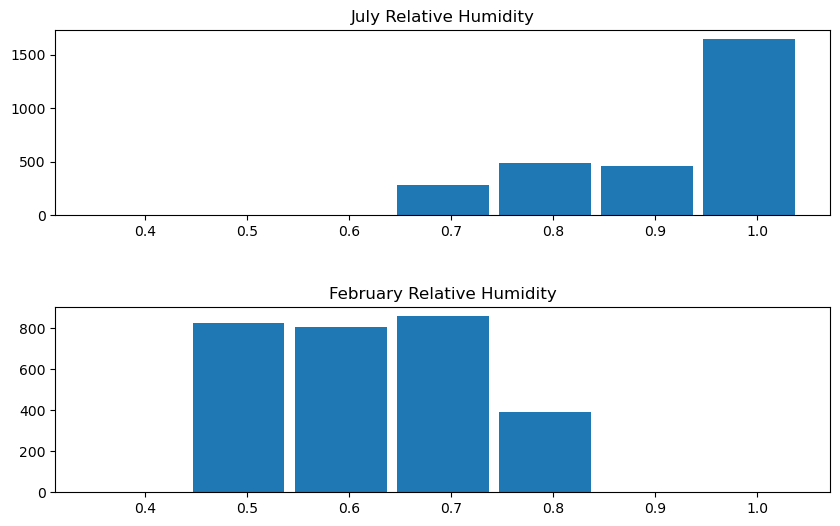

In [14]:
# Generate histogram plots of relative humidity for each day. Use a bin width of 10%. 
fig_hist = plt.figure(figsize=(10,6))
summer_hist, winter_hist = fig_hist.subplots(2,1)
# confused how to use bins
nbins = np.arange(winter_RH.min() - 0.1, summer_RH.max() + 0.1, 0.1)
# Assume did not need to put xlabel ylabel
# summer histogram
summer_hist.hist(summer_RH, bins = nbins, rwidth=0.9)
summer_hist.set_title("July Relative Humidity")
# winter histogram
winter_hist.hist(winter_RH, bins = nbins, rwidth=0.9)
winter_hist.set_title("February Relative Humidity")
# PUt space between subplots
plt.subplots_adjust(hspace = 0.5)

In [15]:
# Calculate the fraction of each day that was ”comfortable” vs ”uncomfortable” 
# (i.e., below vs above 70% relative humidity.) 
summer_comfortable = summer_RH < 0.70
summer_frac = summer_comfortable.sum() / summer_RH.size
# print(summer_comfortable.sum())
# print(summer_RH.size)
print(f"The fraction of a day in July that is comfortable is {summer_frac:.2f}")
print(f"The fraction of a day in July that is uncomfortable is {1-summer_frac:.2f}")
winter_comfortable = winter_RH < 0.70
winter_frac = winter_comfortable.sum() / winter_RH.size
# print(winter_comfortable.sum())
# print(winter_RH.size)
print(f"The fraction of a day in February that is comfortable is {winter_frac:.2f}")
print(f"The fraction of a day in February that is uncomfortable is {1-winter_frac:.2f}")

The fraction of a day in July that is comfortable is 0.06
The fraction of a day in July that is uncomfortable is 0.94
The fraction of a day in February that is comfortable is 0.61
The fraction of a day in February that is uncomfortable is 0.39


#### How comfortable were these days? How do they compare?

6% of a day in July is comfortable while the other 94% is uncomfortable. In other hands, 61% of a day in February is comfortable while the other 39% is uncomfortabel. In a nutshell, a day in February is more comfortable than a day in July. This might be due to a day in February that have lesser value of relative humidity compared to summer's value of relative humidity, which happened due to a bigger gap between the February's air temperature and dew point temperature while there is small or no gap between the July's air temperature and dew point temperature.

## Conclusions
In this lab, we explored that one day in July is hot because the data was taken during summer, which makes air can hold more water vapor. This then making its dew point temperature higher, which lower the gap between dew point temperature and air temperature. Thus, July's relative humidity was always high, if compared to February's data, making it more uncomfortable than comfortable.


## References
List any references used